In [51]:
from dotenv import load_dotenv
import os
import asyncio
import time

import numpy as np
import pandas as pd
import requests
import asyncpraw

import matplotlib.pyplot as plt
import plotly.express as px

from transformers import pipeline
from sqlalchemy import create_engine

load_dotenv(".env")

True

Settings

In [52]:
COINS = [
    "bitcoin",
    "ethereum",
    "solana"
]

LOOKBACK_DAYS = 30
ROLLING_WINDOW = 24
SAVE_TO_DATABASE = False

Load API keys

In [53]:
import os

NEWS_API_KEY = os.getenv("NEWS_API_KEY")

REDDIT_CLIENT_ID = os.getenv("REDDIT_CLIENT_ID")
REDDIT_CLIENT_SECRET = os.getenv("REDDIT_CLIENT_SECRET")
REDDIT_USER_AGENT = os.getenv("REDDIT_USER_AGENT")

BINANCE_API_KEY = os.getenv("BINANCE_API_KEY")
BINANCE_SECRET_KEY = os.getenv("BINANCE_SECRET_KEY")

MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

In [54]:
reddit = asyncpraw.Reddit(
    client_id=REDDIT_CLIENT_ID,
    client_secret=REDDIT_CLIENT_SECRET,
    user_agent=REDDIT_USER_AGENT,
)

# FinBERT sentiment pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

engine = None

if SAVE_TO_DATABASE:
    if all([MYSQL_HOST, MYSQL_USER, MYSQL_PASSWORD, MYSQL_DATABASE]):
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/{MYSQL_DATABASE}"
        )
        print("Database engine initialized")
    else:
        print("Database credentials are missing.")
else:
    print("Database disabled.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Database disabled.


In [55]:
COIN_METADATA = {
    "bitcoin": {
        "symbol": "BTC",
        "binance_pair": "BTCUSDT",
        "search_terms": ["bitcoin", "btc"],
    },
    "ethereum": {
        "symbol": "ETH",
        "binance_pair": "ETHUSDT",
        "search_terms": ["ethereum", "eth"],
    },
    "solana": {
        "symbol": "SOL",
        "binance_pair": "SOLUSDT",
        "search_terms": ["solana", "sol"],
    },
}

Market data from binance

In [56]:
def fetch_binance_data(symbol, interval="1h", limit=500):
    url = "https://data-api.binance.vision/api/v3/klines"

    params = {
        "symbol": symbol,
        "interval": interval,
        "limit": limit,
    }

    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()

    columns = [
        "open_time",
        "open",
        "high",
        "low",
        "close",
        "volume",
        "close_time",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
        "ignore",
    ]

    market_data =pd.DataFrame(response.json(), columns=columns)

    market_data["open_time"] = (
        pd.to_datetime(
            market_data["open_time"],
            unit="ms",
            utc=True
        )
        .dt.tz_convert("America/New_York")
    )
    market_data["hour"] = market_data["open_time"].dt.floor("h")

    market_data["close_time"] = (
        pd.to_datetime(
            market_data["close_time"],
            unit="ms",
            utc=True
        )
        .dt.tz_convert("America/New_York")
    )
    market_data["hour"] = market_data["close_time"].dt.floor("h")

    numeric_columns = [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "quote_asset_volume",
        "number_of_trades",
        "taker_buy_base_volume",
        "taker_buy_quote_volume",
    ]

    market_data[numeric_columns] = market_data[numeric_columns].apply(pd.to_numeric)

    return market_data

In [57]:
btc_market_data = fetch_binance_data(
    symbol=COIN_METADATA["bitcoin"]["binance_pair"],
    interval="1h",
    limit=100,
)

btc_market_data.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,hour
0,2026-07-29 21:00:00-04:00,63696.73,64370.00,63690.00,64266.00,686.07285,2026-07-29 21:59:59.999000-04:00,4.390162e+07,139847,426.85223,2.732137e+07,0,2026-07-29 21:00:00-04:00
1,2026-07-29 22:00:00-04:00,64266.01,64411.76,64159.63,64189.99,575.17340,2026-07-29 22:59:59.999000-04:00,3.698284e+07,122325,248.46096,1.597931e+07,0,2026-07-29 22:00:00-04:00
2,2026-07-29 23:00:00-04:00,64190.00,64300.91,64133.99,64161.98,422.82640,2026-07-29 23:59:59.999000-04:00,2.714304e+07,100176,228.01589,1.463555e+07,0,2026-07-29 23:00:00-04:00
3,2026-07-30 00:00:00-04:00,64161.98,64180.00,64008.50,64023.99,927.45873,2026-07-30 00:59:59.999000-04:00,5.945726e+07,99053,515.31260,3.303417e+07,0,2026-07-30 00:00:00-04:00
4,2026-07-30 01:00:00-04:00,64024.00,64182.00,63907.85,64033.89,766.12333,2026-07-30 01:59:59.999000-04:00,4.903745e+07,145878,345.07237,2.208658e+07,0,2026-07-30 01:00:00-04:00


In [58]:
async def fetch_reddit_posts(
    subreddit_name,
    search_terms,
    limit=100,
):
    posts = []
    subreddit = await reddit.subreddit(subreddit_name)

    for term in search_terms:
        async for post in subreddit.search(
            term,
            sort="new",
            time_filter="month",
            limit=limit,
        ):
            posts.append(
                {
                    "post_id": post.id,
                    "search_term": term,
                    "title": post.title,
                    "body": post.selftext,
                    "num_comments": post.num_comments,
                    "created_at": pd.to_datetime(
                        post.created_utc,
                        unit="s",
                    ),
                    "reddit_url": f"https://reddit.com{post.permalink}",
                    "external_url": post.url,
                }
            )
    reddit_data = pd.DataFrame(posts)

    if not reddit_data.empty:
        reddit_data = reddit_data.drop_duplicates(
            subset="post_id"
        ).reset_index(drop=True)
    return reddit_data

In [59]:
btc_reddit_data = await fetch_reddit_posts(
    subreddit_name="CryptoCUrrency",
    search_terms=COIN_METADATA["bitcoin"]["search_terms"],
    limit=25,
)

display(btc_reddit_data.head())
print(btc_reddit_data.shape)

,post_id,search_term,title,body,num_comments,created_at,reddit_url,external_url
0,1ve0a0b,bitcoin,SEC keeps Nasdaq bitcoin options on hold after...,,3,2026-08-03 02:01:19,https://reddit.com/r/CryptoCurrency/comments/1...,https://www.theblock.co/post/410373/sec-keeps-...
1,1vduqya,bitcoin,On trusting third parties: Bitcoin core vs har...,,3,2026-08-02 21:53:58,https://reddit.com/r/CryptoCurrency/comments/1...,/r/Bitcoin/comments/1vduqif/on_trusting_third_...
2,1vdqfao,bitcoin,Coinkite is manipulating /r/bitcoin subreddit ...,,4,2026-08-02 19:01:54,https://reddit.com/r/CryptoCurrency/comments/1...,/r/bitcoin_uncensored/comments/3qkj1d/coinkite...
3,1vdomgj,bitcoin,Bitcoin Quantum Threat: The Race To Quantum-Pr...,**Is the race toward quantum-safe crypto alrea...,23,2026-08-02 17:52:46,https://reddit.com/r/CryptoCurrency/comments/1...,https://www.forbes.com/sites/boazsobrado/2026/...
4,1vdge27,bitcoin,Weelll another month passed and the only thing...,,33,2026-08-02 12:06:33,https://reddit.com/r/CryptoCurrency/comments/1...,https://i.redd.it/iulkaictcygh1.png


(42, 8)


In [60]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

btc_reddit_data["text"] = (
    btc_reddit_data["title"].fillna("")
    + " "
    + btc_reddit_data["body"].fillna("")
)

def get_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]
        return result["label"], result["score"]
    except Exception:
        return None, None

btc_reddit_data[["sentiment", "confidence"]] = (
    btc_reddit_data["text"]
    .apply(get_sentiment)
    .apply(pd.Series)
)

btc_reddit_data.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,post_id,search_term,title,body,num_comments,created_at,reddit_url,external_url,text,sentiment,confidence
0,1ve0a0b,bitcoin,SEC keeps Nasdaq bitcoin options on hold after...,,3,2026-08-03 02:01:19,https://reddit.com/r/CryptoCurrency/comments/1...,https://www.theblock.co/post/410373/sec-keeps-...,SEC keeps Nasdaq bitcoin options on hold after...,neutral,0.648686
1,1vduqya,bitcoin,On trusting third parties: Bitcoin core vs har...,,3,2026-08-02 21:53:58,https://reddit.com/r/CryptoCurrency/comments/1...,/r/Bitcoin/comments/1vduqif/on_trusting_third_...,On trusting third parties: Bitcoin core vs har...,neutral,0.819013
2,1vdqfao,bitcoin,Coinkite is manipulating /r/bitcoin subreddit ...,,4,2026-08-02 19:01:54,https://reddit.com/r/CryptoCurrency/comments/1...,/r/bitcoin_uncensored/comments/3qkj1d/coinkite...,Coinkite is manipulating /r/bitcoin subreddit ...,positive,0.550986
3,1vdomgj,bitcoin,Bitcoin Quantum Threat: The Race To Quantum-Pr...,**Is the race toward quantum-safe crypto alrea...,23,2026-08-02 17:52:46,https://reddit.com/r/CryptoCurrency/comments/1...,https://www.forbes.com/sites/boazsobrado/2026/...,Bitcoin Quantum Threat: The Race To Quantum-Pr...,neutral,0.481260
4,1vdge27,bitcoin,Weelll another month passed and the only thing...,,33,2026-08-02 12:06:33,https://reddit.com/r/CryptoCurrency/comments/1...,https://i.redd.it/iulkaictcygh1.png,Weelll another month passed and the only thing...,neutral,0.841847


In [61]:
sentiment_map = {
    "positive": 1,
    "negative": -1,
    "neutral": 0
}

btc_reddit_data["sentiment_score"] = (
    btc_reddit_data["sentiment"]
    .str.lower()
    .map(sentiment_map)
)

btc_reddit_data[
    ["title", "sentiment", "confidence", "sentiment_score"]
].head(10)

,title,sentiment,confidence,sentiment_score
0,SEC keeps Nasdaq bitcoin options on hold after...,neutral,0.648686,0
1,On trusting third parties: Bitcoin core vs har...,neutral,0.819013,0
2,Coinkite is manipulating /r/bitcoin subreddit ...,positive,0.550986,1
3,Bitcoin Quantum Threat: The Race To Quantum-Pr...,neutral,0.481260,0
4,Weelll another month passed and the only thing...,neutral,0.841847,0
5,Coldcard Hack Expands as Bitcoin Losses Reach ...,positive,0.753544,1
6,[SERIOUS] Does self-custody make cryptocurrenc...,neutral,0.731215,0
7,Muun wallet for long term storage?,neutral,0.943190,0
8,Security Isn't Optional. It's Everything,neutral,0.925129,0
9,I’m done with crypto after seeing what keeps h...,neutral,0.694434,0


In [62]:
btc_reddit_data["created_at"] = (
    pd.to_datetime(btc_reddit_data["created_at"], utc=True)
    .dt.tz_convert("America/New_York")
)
btc_reddit_data["hour"] = (
    btc_reddit_data["created_at"]
    .dt.floor("h")
)
btc_reddit_data["hour_display"] = (
    btc_reddit_data["hour"]
    .dt.strftime("%Y-%m-%d %I:%M %p") #this helps my mild dyslexia
)

hourly_sentiment = (
    btc_reddit_data
    .groupby("hour")
    .agg(
        average_sentiment=("sentiment_score", "mean"),
        mentions=("post_id", "count"),
        average_confidence=("confidence", "mean")
    )
    .reset_index()
)
hourly_sentiment.head()

,hour,average_sentiment,mentions,average_confidence
0,2026-07-29 07:00:00-04:00,0.0,1,0.812884
1,2026-07-29 09:00:00-04:00,0.0,1,0.929106
2,2026-07-29 11:00:00-04:00,0.0,1,0.942986
3,2026-07-30 00:00:00-04:00,0.0,1,0.679019
4,2026-07-30 09:00:00-04:00,0.0,1,0.849449


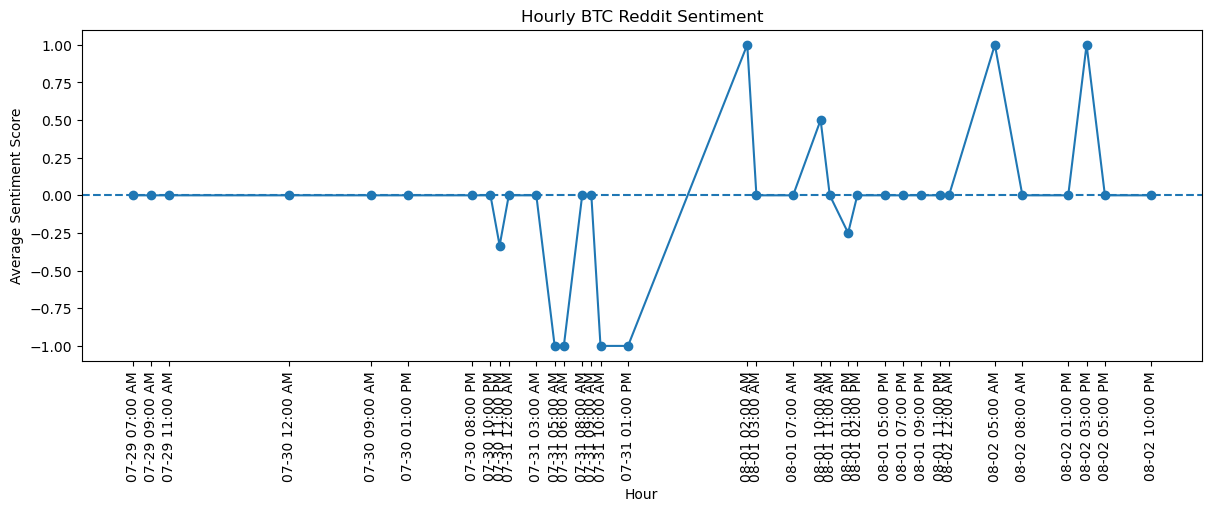

In [63]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(
    hourly_sentiment["hour"],
    hourly_sentiment["average_sentiment"],
    marker="o"
)
plt.axhline(0, linestyle="--")
plt.title("Hourly BTC Reddit Sentiment")
plt.xlabel("Hour")
plt.ylabel("Average Sentiment Score")
plt.xticks(
    hourly_sentiment["hour"],
    hourly_sentiment["hour"].dt.strftime("%m-%d %I:%M %p"),
    rotation=90
)
plt.show()

In [66]:
btc_combined_data = pd.merge(
    btc_market_data,
    hourly_sentiment,
    on="hour",
    how="left"
)

btc_combined_data["average_sentiment"] = (
    btc_combined_data["average_sentiment"].fillna(0)
)

btc_combined_data["mentions"] = (
    btc_combined_data["mentions"].fillna(0)
)

btc_combined_data["average_confidence"] = (
    btc_combined_data["average_confidence"].fillna(0)
)

btc_combined_data[
    ["hour", "average_sentiment", "mentions"]
].head()

,hour,average_sentiment,mentions
0,2026-07-29 21:00:00-04:00,0.0,0.0
1,2026-07-29 22:00:00-04:00,0.0,0.0
2,2026-07-29 23:00:00-04:00,0.0,0.0
3,2026-07-30 00:00:00-04:00,0.0,1.0
4,2026-07-30 01:00:00-04:00,0.0,0.0
